In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

print(f"numpy version {np.__version__}")
print(f"pandas version {pd.__version__}")

numpy version 1.26.4
pandas version 2.2.2


In [2]:
data = pd.read_csv('fr-en-annuaire-education (5).csv', encoding='latin-1', delimiter=';')

C:\Users\HP\AppData\Local\Temp\ipykernel_19152\3147372607.py:1: DtypeWarning: Columns (9,11,23,24,43,44,60) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('fr-en-annuaire-education (5).csv', encoding='latin-1', delimiter=';')


In [3]:
data.head(7)

,Identifiant_de_l_etablissement,Type_etablissement,Statut_public_prive,Type_contrat_prive,Nom_etablissement,Adresse_1,Adresse_2,Adresse_3,Code_postal,Code_commune,...,precision_localisation,date_ouverture,date_maj_ligne,etat,ministere_tutelle,multi_uai,rpi_concentre,rpi_disperse,code_nature,libelle_nature
0,0011432B,Ecole,Public,SANS OBJET,Ecole primaire publique la Diamanterie,431 rue Simone Veil,NaN,01630 ST GENIS POUILLY,1630,01354,...,Rue,2018-09-01,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,0.0,NaN,151,ECOLE DE NIVEAU ELEMENTAIRE
1,0022188T,Ecole,Privé,HORS CONTRAT,Chouette Ecole,9 rue des sources,NaN,02380 VERNEUIL SOUS COUCY,2380,02786,...,NaN,2019-09-01,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,0.0,NaN,151,ECOLE DE NIVEAU ELEMENTAIRE
2,0050650E,Ecole,Public,SANS OBJET,ECOLE PRIMAIRE PUBLIQUE REOTIER - ST CLÉMENT S...,Lieu-dit la Clapière LA CLAPIÈRE,NaN,05600 ST CLEMENT SUR DURANCE,5600,05134,...,Numéro de rue,2015-09-01,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,1.0,NaN,151,ECOLE DE NIVEAU ELEMENTAIRE
3,0060571N,Ecole,Public,SANS OBJET,Ecole maternelle Sospel,Boulevard Jules Ferry,NaN,06380 SOSPEL,6380,06136,...,Numéro de rue,1965-07-12,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,0.0,NaN,101,ECOLE MATERNELLE
4,0070132F,Ecole,Public,SANS OBJET,Ecole primaire,Quartier Dumont,NaN,07140 GRAVIERES,7140,07100,...,Numéro de rue,1966-10-14,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,1.0,NaN,151,ECOLE DE NIVEAU ELEMENTAIRE
5,0070139N,Ecole,Public,SANS OBJET,Ecole primaire,LE VILLAGE,NaN,07140 LES ASSIONS,7140,07017,...,Ville,1966-09-22,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,0.0,NaN,151,ECOLE DE NIVEAU ELEMENTAIRE
6,0070188S,Ecole,Public,SANS OBJET,Ecole primaire,LE VILLAGE,NaN,07230 CHANDOLAS,7230,07053,...,Ville,1966-10-01,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,0.0,NaN,151,ECOLE DE NIVEAU ELEMENTAIRE


In [4]:
# Remove insignificant variables
dataD = data.drop(['Identifiant_de_l_etablissement', 'Nom_etablissement', 'Adresse_1' , 'Adresse_2' , 'Adresse_3' , 'Nom_commune' , 'Libelle_departement' , 'Libelle_academie' , 'Libelle_region' , 'Telephone' , 'Fax' , 'Mail' , 'Post_BAC' , 'SIREN_SIRET' , 'Fiche_onisep' , 'coordX_origine' , 'coordY_origine' , 'epsg_origine' , 'nom_circonscription' , 'latitude' , 'longitude' , 'position' , 'precision_localisation' , 'date_maj_ligne' , 'ministere_tutelle' , 'Ecole_elementaire','Ecole_maternelle' , 'rpi_disperse' ,'Web',], axis=1)

In [5]:
dataD.head(7)

,Type_etablissement,Statut_public_prive,Type_contrat_prive,Code_postal,Code_commune,Code_departement,Code_academie,Code_region,Voie_generale,Voie_technologique,...,Lycee_militaire,Nombre_d_eleves,GRETA,Appartenance_Education_Prioritaire,date_ouverture,etat,multi_uai,rpi_concentre,code_nature,libelle_nature
0,Ecole,Public,SANS OBJET,1630,01354,01,10,84,NaN,NaN,...,NaN,NaN,NaN,NaN,2018-09-01,OUVERT,0,0.0,151,ECOLE DE NIVEAU ELEMENTAIRE
1,Ecole,Privé,HORS CONTRAT,2380,02786,02,20,32,NaN,NaN,...,NaN,NaN,NaN,NaN,2019-09-01,OUVERT,0,0.0,151,ECOLE DE NIVEAU ELEMENTAIRE
2,Ecole,Public,SANS OBJET,5600,05134,05,2,93,NaN,NaN,...,NaN,32.0,NaN,NaN,2015-09-01,OUVERT,0,1.0,151,ECOLE DE NIVEAU ELEMENTAIRE
3,Ecole,Public,SANS OBJET,6380,06136,06,23,93,NaN,NaN,...,NaN,135.0,NaN,NaN,1965-07-12,OUVERT,0,0.0,101,ECOLE MATERNELLE
4,Ecole,Public,SANS OBJET,7140,07100,07,8,84,NaN,NaN,...,NaN,59.0,NaN,NaN,1966-10-14,OUVERT,0,1.0,151,ECOLE DE NIVEAU ELEMENTAIRE
5,Ecole,Public,SANS OBJET,7140,07017,07,8,84,NaN,NaN,...,NaN,59.0,NaN,NaN,1966-09-22,OUVERT,0,0.0,151,ECOLE DE NIVEAU ELEMENTAIRE
6,Ecole,Public,SANS OBJET,7230,07053,07,8,84,NaN,NaN,...,NaN,12.0,NaN,NaN,1966-10-01,OUVERT,0,0.0,151,ECOLE DE NIVEAU ELEMENTAIRE


In [6]:
dataD.shape

(65404, 34)

In [7]:
# 4️⃣ Nettoyer les doublons
nb_doublons = dataD.duplicated().sum()
print(f"\n🔁 Nombre de doublons trouvés : {nb_doublons}")

if nb_doublons > 0:
    dataD = dataD.drop_duplicates()
    print("✅ Doublons supprimés.")


🔁 Nombre de doublons trouvés : 604
✅ Doublons supprimés.


In [8]:
 dataD.isnull().sum()

Type_etablissement                        0
Statut_public_prive                    1685
Type_contrat_prive                     2128
Code_postal                               0
Code_commune                              0
Code_departement                          0
Code_academie                             0
Code_region                               0
Voie_generale                         52762
Voie_technologique                    52762
Voie_professionnelle                  52762
Restauration                           2125
Hebergement                            2125
ULIS                                   2125
Lycee_des_metiers                     52761
Apprentissage                         52762
Segpa                                 52762
Section_arts                          52762
Section_cinema                        52762
Section_theatre                       52762
Section_sport                         52762
Section_internationale                52762
Section_europeenne              

In [9]:
cols = ['Voie_generale', 'Voie_technologique', 'Voie_professionnelle']

# remplacer par 0 si type_etab n'est ni college ni lycee
dataD.loc[~dataD['Type_etablissement'].isin(['collège', 'lycée']), cols] = 0

In [10]:
dataD[['Voie_generale', 'Voie_technologique', 'Voie_professionnelle']].isnull().sum()


Voie_generale           0
Voie_technologique      0
Voie_professionnelle    0
dtype: int64

In [11]:
sections = [
    'Section_arts', 'Section_cinema', 'Section_theatre',
    'Section_sport', 'Section_internationale', 'Section_europeenne'
]

dataD.loc[dataD[sections].isnull().any(axis=1), 'Type_etablissement'].value_counts()


Type_etablissement
Ecole                         50636
Service Administratif          1685
Information et orientation      440
Collège                           1
Name: count, dtype: int64

In [12]:
sections = [
    'Section_arts', 'Section_cinema', 'Section_theatre',
    'Section_sport', 'Section_internationale', 'Section_europeenne'
]

# Liste des types autorisés
types_autorises = ["Collège", "Lycée", "EREA"]

# Mettre les sections à 0 si le type n'est pas autorisé
dataD.loc[~dataD['Type_etablissement'].isin(types_autorises), sections] = 0


In [13]:
dataD[sections].isnull().sum()

Section_arts              1
Section_cinema            1
Section_theatre           1
Section_sport             1
Section_internationale    1
Section_europeenne        1
dtype: int64

In [14]:
# Liste des valeurs autorisées
types_autorises = ["Lycée", "Collège", "EREA"]

# Liste des colonnes à remettre à 0
colonnes_lycee = ["Lycee_Agricole", "Lycee_militaire", "Lycee_des_metiers"]

# Remplacer par 0 si Type_etablissement n'est pas dans types_autorises
dataD.loc[~dataD["Type_etablissement"].isin(types_autorises), colonnes_lycee] = 0


In [15]:
dataD[colonnes_lycee].isnull().sum()

Lycee_Agricole       1
Lycee_militaire      1
Lycee_des_metiers    0
dtype: int64

In [16]:
colonnes_lycee = ["Lycee_Agricole", "Lycee_militaire", "Lycee_des_metiers"]

# Supprimer les lignes où Lycee_Agricole ou Lycee_militaire est NaN
dataD = dataD.dropna(subset=["Lycee_Agricole", "Lycee_militaire"])

In [17]:
dataD[colonnes_lycee].isnull().sum()

Lycee_Agricole       0
Lycee_militaire      0
Lycee_des_metiers    0
dtype: int64

In [18]:
colonnes_lycee = ["Lycee_Agricole", "Lycee_militaire", "Lycee_des_metiers"]

# Supprimer les lignes où Lycee_Agricole ou Lycee_militaire est NaN
dataD = dataD.dropna(subset=["Lycee_Agricole", "Lycee_militaire"])


In [19]:
dataD['Nombre_d_eleves'] = pd.to_numeric(dataD['Nombre_d_eleves'], errors='coerce')
dataD['Nombre_d_eleves'] = dataD['Nombre_d_eleves'].fillna(dataD['Nombre_d_eleves'].median())

In [20]:
dataD.isnull().sum()

Type_etablissement                        0
Statut_public_prive                    1685
Type_contrat_prive                     2128
Code_postal                               0
Code_commune                              0
Code_departement                          0
Code_academie                             0
Code_region                               0
Voie_generale                             0
Voie_technologique                        0
Voie_professionnelle                      0
Restauration                           2125
Hebergement                            2125
ULIS                                   2125
Lycee_des_metiers                         0
Apprentissage                         52761
Segpa                                 52761
Section_arts                              0
Section_cinema                            0
Section_theatre                           0
Section_sport                             0
Section_internationale                    0
Section_europeenne              

In [21]:
sections = [
    'Section_arts', 'Section_cinema', 'Section_theatre',
    'Section_sport', 'Section_internationale', 'Section_europeenne'
]

dataD.loc[
    (dataD['Type_etablissement'].isin(['Ecole'])) &
    (dataD[sections].isnull().all(axis=1)),
    sections
] = 0
dataD.loc[
    (dataD['Type_etablissement'] == 'Collège') &
    (dataD[sections].isnull().all(axis=1)),
    sections
] = 0


In [22]:
dataD.isnull().sum()

Type_etablissement                        0
Statut_public_prive                    1685
Type_contrat_prive                     2128
Code_postal                               0
Code_commune                              0
Code_departement                          0
Code_academie                             0
Code_region                               0
Voie_generale                             0
Voie_technologique                        0
Voie_professionnelle                      0
Restauration                           2125
Hebergement                            2125
ULIS                                   2125
Lycee_des_metiers                         0
Apprentissage                         52761
Segpa                                 52761
Section_arts                              0
Section_cinema                            0
Section_theatre                           0
Section_sport                             0
Section_internationale                    0
Section_europeenne              

In [23]:
dataD['rpi_concentre'].value_counts()

rpi_concentre
0.0    60942
1.0     1732
Name: count, dtype: int64

In [24]:
dataD['rpi_concentre'] = dataD['rpi_concentre'].fillna(0.0)

In [25]:
dataD['Restauration'].value_counts()

Restauration
1.0    46819
0.0    15855
Name: count, dtype: int64

In [26]:
def remplir_appartenance(row):
    if pd.isnull(row['Appartenance_Education_Prioritaire']):
        if row['Type_etablissement'] == 'Ecole':
            return "Aucune"
        else:
            return "REP-"
    else:
        return row['Appartenance_Education_Prioritaire']

# Appliquer la fonction
dataD['Appartenance_Education_Prioritaire'] = dataD.apply(remplir_appartenance, axis=1)


In [27]:
dataD['Appartenance_Education_Prioritaire'].value_counts(dropna=False)


Appartenance_Education_Prioritaire
Aucune    43966
REP-      13068
REP        4926
REP+       2839
Name: count, dtype: int64

In [28]:
dataD['Appartenance_Education_Prioritaire'].isnull().sum()

0

In [29]:
dataD.isnull().sum()

Type_etablissement                        0
Statut_public_prive                    1685
Type_contrat_prive                     2128
Code_postal                               0
Code_commune                              0
Code_departement                          0
Code_academie                             0
Code_region                               0
Voie_generale                             0
Voie_technologique                        0
Voie_professionnelle                      0
Restauration                           2125
Hebergement                            2125
ULIS                                   2125
Lycee_des_metiers                         0
Apprentissage                         52761
Segpa                                 52761
Section_arts                              0
Section_cinema                            0
Section_theatre                           0
Section_sport                             0
Section_internationale                    0
Section_europeenne              

In [30]:
# Filtrer les lignes où Apprentissage est null
apprentissage_null = dataD[dataD['Apprentissage'].isnull()]

# Afficher les types d'établissement distincts
types_etab_null = apprentissage_null['Type_etablissement'].unique()


print(types_etab_null)


['Ecole' 'Information et orientation' 'Service Administratif']


In [31]:
# Types pour lesquels Apprentissage peut être NaN
types_autorises_nan = ['Ecole', 'Information et orientation', 'Service Administratif']

# Condition : type d'établissement différent des types autorisés
condition = dataD['Type_etablissement'].isin(types_autorises_nan)

# Appliquer la règle : Apprentissage = 0
dataD.loc[condition, 'Apprentissage'] = 0


In [32]:
dataD.loc[condition, 'Apprentissage'].unique()


array([0.])

In [33]:
types_nan_hebergement = dataD[dataD['Hebergement'].isnull()]['Type_etablissement'].unique()
print(types_nan_hebergement)


['Information et orientation' 'Service Administratif']


In [34]:
types_nan_restauration = dataD[dataD['Restauration'].isnull()]['Type_etablissement'].unique()
print(types_nan_restauration)


['Information et orientation' 'Service Administratif']


In [35]:
types_nan_ulis = dataD[dataD['ULIS'].isnull()]['Type_etablissement'].unique()
print(types_nan_ulis)


['Information et orientation' 'Service Administratif']


In [36]:
# Liste des types concernés
types_cibles = ['Information et orientation', 'Service Administratif']

# Condition : lignes où le type correspond
condition = dataD['Type_etablissement'].isin(types_cibles)

# Mettre les colonnes à 0 quand condition vraie
dataD.loc[condition, ['Restauration', 'ULIS', 'Hebergement']] = 0


In [37]:
dataD.isnull().sum()

Type_etablissement                        0
Statut_public_prive                    1685
Type_contrat_prive                     2128
Code_postal                               0
Code_commune                              0
Code_departement                          0
Code_academie                             0
Code_region                               0
Voie_generale                             0
Voie_technologique                        0
Voie_professionnelle                      0
Restauration                              0
Hebergement                               0
ULIS                                      0
Lycee_des_metiers                         0
Apprentissage                             0
Segpa                                 52761
Section_arts                              0
Section_cinema                            0
Section_theatre                           0
Section_sport                             0
Section_internationale                    0
Section_europeenne              

In [38]:
# Filtrer les lignes où Apprentissage est null
greta_null = dataD[dataD['GRETA'].isnull()]

# Afficher les types d'établissement distincts
types_etab_null = greta_null['Type_etablissement'].unique()

print(types_etab_null)

['Ecole' 'Information et orientation' 'Service Administratif']


In [39]:
# Types for which GRETA can be NaN
types_autorises_nan_greta = ['Ecole', 'Information et orientation', 'Service Administratif']

# Condition: type d'établissement is one of the authorized types
condition_greta = dataD['Type_etablissement'].isin(types_autorises_nan_greta)

# Apply the rule: GRETA = 0
dataD.loc[condition_greta, 'GRETA'] = 0

# Verify null counts for GRETA after filling NaNs
print(dataD['GRETA'].isnull().sum())

0


In [40]:
dataD.isnull().sum()

Type_etablissement                        0
Statut_public_prive                    1685
Type_contrat_prive                     2128
Code_postal                               0
Code_commune                              0
Code_departement                          0
Code_academie                             0
Code_region                               0
Voie_generale                             0
Voie_technologique                        0
Voie_professionnelle                      0
Restauration                              0
Hebergement                               0
ULIS                                      0
Lycee_des_metiers                         0
Apprentissage                             0
Segpa                                 52761
Section_arts                              0
Section_cinema                            0
Section_theatre                           0
Section_sport                             0
Section_internationale                    0
Section_europeenne              

In [41]:
# Filtrer les lignes où Apprentissage est null
Segpa_null = dataD[dataD['Segpa'].isnull()]

# Afficher les types d'établissement distincts
types_etab_null = Segpa_null['Type_etablissement'].unique()

print(types_etab_null)

['Ecole' 'Information et orientation' 'Service Administratif']


In [42]:
# Types for which Segpa can be NaN
types_autorises_nan_Segpa = ['Ecole', 'Information et orientation', 'Service Administratif']

# Condition: type d'établissement is one of the authorized types
condition_Segpa = dataD['Type_etablissement'].isin(types_autorises_nan_Segpa)

# Apply the rule: Segpa = 0
dataD.loc[condition_Segpa, 'Segpa'] = 0

# Verify null counts for Segpa after filling NaNs
print(dataD['Segpa'].isnull().sum())

0


In [43]:
dataD.isnull().sum()

Type_etablissement                       0
Statut_public_prive                   1685
Type_contrat_prive                    2128
Code_postal                              0
Code_commune                             0
Code_departement                         0
Code_academie                            0
Code_region                              0
Voie_generale                            0
Voie_technologique                       0
Voie_professionnelle                     0
Restauration                             0
Hebergement                              0
ULIS                                     0
Lycee_des_metiers                        0
Apprentissage                            0
Segpa                                    0
Section_arts                             0
Section_cinema                           0
Section_theatre                          0
Section_sport                            0
Section_internationale                   0
Section_europeenne                       0
Lycee_Agric

In [44]:
dataD[dataD['Statut_public_prive'].isnull()]['Type_etablissement'].unique()


array(['Service Administratif'], dtype=object)

In [45]:
# Remplacer Statut_public_prive par "Aucune" si type d'établissement = Service Administratif
dataD.loc[dataD['Type_etablissement'] == 'Service Administratif', 'Statut_public_prive'] = 'Aucune'


In [46]:
# Vérifier les valeurs uniques pour Service Administratif
dataD[dataD['Type_etablissement'] == 'Service Administratif']['Statut_public_prive'].unique()


array(['Aucune'], dtype=object)

In [47]:
dataD.isnull().sum()

Type_etablissement                       0
Statut_public_prive                      0
Type_contrat_prive                    2128
Code_postal                              0
Code_commune                             0
Code_departement                         0
Code_academie                            0
Code_region                              0
Voie_generale                            0
Voie_technologique                       0
Voie_professionnelle                     0
Restauration                             0
Hebergement                              0
ULIS                                     0
Lycee_des_metiers                        0
Apprentissage                            0
Segpa                                    0
Section_arts                             0
Section_cinema                           0
Section_theatre                          0
Section_sport                            0
Section_internationale                   0
Section_europeenne                       0
Lycee_Agric

In [48]:
dataD[dataD['Type_contrat_prive'].isnull()]['Type_etablissement'].unique()


array(['Ecole', 'Information et orientation', 'Service Administratif'],
      dtype=object)

In [49]:
# Liste des types d'établissement concernés
types_cibles = ['Ecole', 'Information et orientation', 'Service Administratif']

# Appliquer la règle
dataD.loc[dataD['Type_etablissement'].isin(types_cibles), 'Type_contrat_prive'] = 'Aucun'


In [50]:
# Vérifier les valeurs uniques après modification
dataD[dataD['Type_etablissement'].isin(types_cibles)]['Type_contrat_prive'].unique()


array(['Aucun'], dtype=object)

In [51]:
dataD.isnull().sum()

Type_etablissement                    0
Statut_public_prive                   0
Type_contrat_prive                    0
Code_postal                           0
Code_commune                          0
Code_departement                      0
Code_academie                         0
Code_region                           0
Voie_generale                         0
Voie_technologique                    0
Voie_professionnelle                  0
Restauration                          0
Hebergement                           0
ULIS                                  0
Lycee_des_metiers                     0
Apprentissage                         0
Segpa                                 0
Section_arts                          0
Section_cinema                        0
Section_theatre                       0
Section_sport                         0
Section_internationale                0
Section_europeenne                    0
Lycee_Agricole                        0
Lycee_militaire                       0


In [52]:
dataD = dataD.drop(columns=['multi_uai'])



In [53]:
dataD.isnull().sum()

Type_etablissement                    0
Statut_public_prive                   0
Type_contrat_prive                    0
Code_postal                           0
Code_commune                          0
Code_departement                      0
Code_academie                         0
Code_region                           0
Voie_generale                         0
Voie_technologique                    0
Voie_professionnelle                  0
Restauration                          0
Hebergement                           0
ULIS                                  0
Lycee_des_metiers                     0
Apprentissage                         0
Segpa                                 0
Section_arts                          0
Section_cinema                        0
Section_theatre                       0
Section_sport                         0
Section_internationale                0
Section_europeenne                    0
Lycee_Agricole                        0
Lycee_militaire                       0


In [54]:
etat = pd.get_dummies(dataD.etat).iloc[:,1:]
Statut_public_prive = pd.get_dummies(dataD.Statut_public_prive).iloc[:,1:]
Type_contrat_prive = pd.get_dummies(dataD.Type_contrat_prive).iloc[:,1:]
Type_etablissement = pd.get_dummies(dataD.Type_etablissement).iloc[:,1:]
Appartenance_Education_Prioritaire = pd.get_dummies(dataD.Appartenance_Education_Prioritaire).iloc[:,1:]
libelle_nature = pd.get_dummies(dataD.libelle_nature).iloc[:,1:]



In [55]:
dataD =  dataD.drop(['etat', 'Statut_public_prive' ,'Type_contrat_prive','Type_etablissement','Appartenance_Education_Prioritaire','libelle_nature'], axis=1)

In [56]:
dataset = pd.concat([dataD,etat,Statut_public_prive,Type_contrat_prive,Type_etablissement,Appartenance_Education_Prioritaire,libelle_nature], axis=1)
dataset.head()

,Code_postal,Code_commune,Code_departement,Code_academie,Code_region,Voie_generale,Voie_technologique,Voie_professionnelle,Restauration,Hebergement,...,LYCEE ENS GENERAL TECHNO PROF AGRICOLE,LYCEE ENSEIGNT GENERAL ET TECHNOLOGIQUE,LYCEE POLYVALENT,LYCEE PROFESSIONNEL,RECTORAT,SECTION D ENSEIGNEMENT PROFESSIONNEL,SECTION ENSEIGT GENERAL ET TECHNOLOGIQUE,SERVICE DE LA DSDEN,SERVICE RECTORAL,VICE RECTORAT TOM
0,1630,01354,01,10,84,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2380,02786,02,20,32,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,5600,05134,05,2,93,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,6380,06136,06,23,93,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,7140,07100,07,8,84,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [57]:
print(dataset.columns)


Index(['Code_postal', 'Code_commune', 'Code_departement', 'Code_academie',
       'Code_region', 'Voie_generale', 'Voie_technologique',
       'Voie_professionnelle', 'Restauration', 'Hebergement', 'ULIS',
       'Lycee_des_metiers', 'Apprentissage', 'Segpa', 'Section_arts',
       'Section_cinema', 'Section_theatre', 'Section_sport',
       'Section_internationale', 'Section_europeenne', 'Lycee_Agricole',
       'Lycee_militaire', 'Nombre_d_eleves', 'GRETA', 'date_ouverture',
       'rpi_concentre', 'code_nature', 'OUVERT', 'Aucune', 'Privé', 'Public',
       'CONTRAT ASSOCIATION PARTIE DES CLASSES',
       'CONTRAT D'ASSOCIATION TOUTES CLASSES', 'CONTRAT SIMPLE TOUTES CLASSES',
       'HORS CONTRAT', 'SANS OBJET', 'EREA', 'Ecole',
       'Information et orientation', 'Lycée', 'Service Administratif', 'REP',
       'REP+', 'REP-', 'CENTRE D INFORMATION ET D ORIENTATION', 'CETAD (TOM)',
       'CIRCONSCRIPTIONS INSPECTION EDUC NAT', 'COLLEGE', 'COLLEGE CLIMATIQUE',
       'COLLEGE SPEC

In [58]:
dataset.shape

(64799, 80)

In [59]:
print(dataset.dtypes)


Code_postal                                  int64
Code_commune                                object
Code_departement                            object
Code_academie                                int64
Code_region                                  int64
                                             ...  
SECTION D ENSEIGNEMENT PROFESSIONNEL          bool
SECTION ENSEIGT GENERAL ET TECHNOLOGIQUE      bool
SERVICE DE LA DSDEN                           bool
SERVICE RECTORAL                              bool
VICE RECTORAT TOM                             bool
Length: 80, dtype: object


In [60]:
obj_cols = dataset.select_dtypes(include='object').columns
print("Colonnes object :", obj_cols.tolist())


Colonnes object : ['Code_commune', 'Code_departement', 'date_ouverture']


In [61]:
# Valeurs uniques de Code_commune
print(dataset['Code_commune'].unique())

# Valeurs uniques de Code_departement
print(dataset['Code_departement'].unique())


['01354' '02786' '05134' ... '94048' '94056' '94053']
['01' '02' '05' '06' '07' '08' '11' '13' '17' '18' '19' '21' '22' '24'
 '26' '30' '31' '33' '34' '37' '38' '39' '43' '44' '45' '47' '49' '50'
 '53' '55' '57' '58' '59' '60' '62' '66' '67' '68' '69' '71' '73' '74'
 '79' '80' '84' '85' '86' '91' '92' '94' '2A' '2B' '972' '973' '974' '976'
 '03' '04' '16' '23' '48' '72' '75' '82' '14' '35' '42' '70' '78' '90'
 '93' '95' '971' '41' '52' '77' '81' '27' '51' '65' '76' '88' '10' '28'
 '87' '978' '987' '29' '32' '40' '61' '12' '25' '36' '09' '15' '46' '54'
 '63' '83' '89' '988' '977' 28 30 36 37 41 45 57 67 68 73 74 78 79 91 92
 95 974 2 35 38 42 60 72 77 85 93 988 13 22 34 55 75 1 3 4 5 11 14 25 26
 27 32 40 43 52 58 66 69 76 84 86 8 6 17 33 61 64 80 63 71 87 16 21 94 47
 89 10 29 39 44 49 50 54 70 976 987 59 51 83 971 7 9 12 15 18 19 23 24 31
 46 48 53 56 62 65 81 82 88 90 '975' '64' '986' '56']


In [62]:
dataset = dataset[~dataset['Code_departement'].isin(['2A', '2B'])]


In [63]:
dataset['Code_departement'] = dataset['Code_departement'].str.strip()
dataset['Code_commune'] = dataset['Code_commune'].str.strip()

In [64]:
dataset['Code_departement'] = dataset['Code_departement'].astype('Int64')
dataset['Code_commune'] = dataset['Code_commune'].astype('Int64')

In [65]:
print(dataset.dtypes)

Code_postal                                 int64
Code_commune                                Int64
Code_departement                            Int64
Code_academie                               int64
Code_region                                 int64
                                            ...  
SECTION D ENSEIGNEMENT PROFESSIONNEL         bool
SECTION ENSEIGT GENERAL ET TECHNOLOGIQUE     bool
SERVICE DE LA DSDEN                          bool
SERVICE RECTORAL                             bool
VICE RECTORAT TOM                            bool
Length: 80, dtype: object


In [66]:
from sklearn.preprocessing import MinMaxScaler

# Colonnes continues à scaler
cols_to_scale = ['Nombre_d_eleves', 'Code_commune', 'Code_departement']

# Vérification que toutes ces colonnes existent dans le dataset
cols_to_scale = [col for col in cols_to_scale if col in dataset.columns]

# Appliquer MinMaxScaler
scaler = MinMaxScaler()
dataset[cols_to_scale] = scaler.fit_transform(dataset[cols_to_scale])

# Vérification
print(dataset[cols_to_scale].head())
print("Min :", dataset[cols_to_scale].min().min(), "Max :", dataset[cols_to_scale].max().max())


   Nombre_d_eleves  Code_commune  Code_departement
0         0.042387      0.003576          0.000000
1         0.042387      0.018204          0.001013
2         0.008803      0.042191          0.004053
3         0.042387      0.052427          0.005066
4         0.017607      0.062275          0.006079
Min : 0.0 Max : 1.0000000000000002


c:\Users\HP\Downloads\ml+bi\venv\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\HP\Downloads\ml+bi\venv\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
c:\Users\HP\Downloads\ml+bi\venv\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\HP\Downloads\ml+bi\venv\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is d

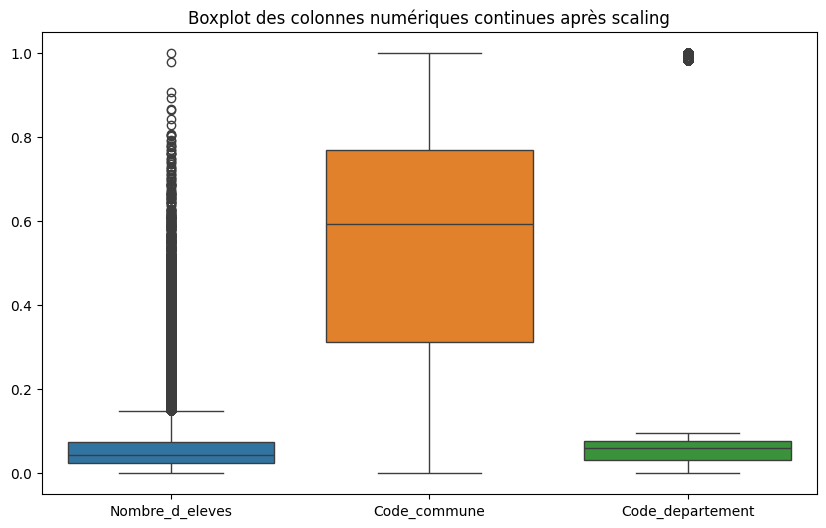

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# Colonnes scalées
cols_to_plot = ['Nombre_d_eleves', 'Code_commune', 'Code_departement']

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=dataset[cols_to_plot])
plt.title("Boxplot des colonnes numériques continues après scaling")
plt.show()


In [68]:
import pandas as pd

# S'assurer que la colonne est bien en format datetime
dataset['date_ouverture'] = pd.to_datetime(dataset['date_ouverture'], errors='coerce')

# Extraire l'année et le mois
dataset['annee_ouverture'] = dataset['date_ouverture'].dt.year
dataset['mois_ouverture'] = dataset['date_ouverture'].dt.month

# Supprimer la colonne originale si tu ne veux plus la garder
# dataset.drop('date_ouverture', axis=1, inplace=True)

# Vérification du résultat
print(dataset[['date_ouverture', 'annee_ouverture', 'mois_ouverture']].head())


  date_ouverture  annee_ouverture  mois_ouverture
0     2018-09-01             2018               9
1     2019-09-01             2019               9
2     2015-09-01             2015               9
3     1965-07-12             1965               7
4     1966-10-14             1966              10


In [69]:
print(dataset.columns)


Index(['Code_postal', 'Code_commune', 'Code_departement', 'Code_academie',
       'Code_region', 'Voie_generale', 'Voie_technologique',
       'Voie_professionnelle', 'Restauration', 'Hebergement', 'ULIS',
       'Lycee_des_metiers', 'Apprentissage', 'Segpa', 'Section_arts',
       'Section_cinema', 'Section_theatre', 'Section_sport',
       'Section_internationale', 'Section_europeenne', 'Lycee_Agricole',
       'Lycee_militaire', 'Nombre_d_eleves', 'GRETA', 'date_ouverture',
       'rpi_concentre', 'code_nature', 'OUVERT', 'Aucune', 'Privé', 'Public',
       'CONTRAT ASSOCIATION PARTIE DES CLASSES',
       'CONTRAT D'ASSOCIATION TOUTES CLASSES', 'CONTRAT SIMPLE TOUTES CLASSES',
       'HORS CONTRAT', 'SANS OBJET', 'EREA', 'Ecole',
       'Information et orientation', 'Lycée', 'Service Administratif', 'REP',
       'REP+', 'REP-', 'CENTRE D INFORMATION ET D ORIENTATION', 'CETAD (TOM)',
       'CIRCONSCRIPTIONS INSPECTION EDUC NAT', 'COLLEGE', 'COLLEGE CLIMATIQUE',
       'COLLEGE SPEC

In [70]:
# Supprimer complètement la colonne date_ouverture
dataset = dataset.drop(columns=['date_ouverture'])


In [71]:
import gc

gc.collect()

try:
    torch.cuda.empty_cache()
except:
    pass


obj: classifier par etat **claasification**

In [72]:
print(dataset.columns)


Index(['Code_postal', 'Code_commune', 'Code_departement', 'Code_academie',
       'Code_region', 'Voie_generale', 'Voie_technologique',
       'Voie_professionnelle', 'Restauration', 'Hebergement', 'ULIS',
       'Lycee_des_metiers', 'Apprentissage', 'Segpa', 'Section_arts',
       'Section_cinema', 'Section_theatre', 'Section_sport',
       'Section_internationale', 'Section_europeenne', 'Lycee_Agricole',
       'Lycee_militaire', 'Nombre_d_eleves', 'GRETA', 'rpi_concentre',
       'code_nature', 'OUVERT', 'Aucune', 'Privé', 'Public',
       'CONTRAT ASSOCIATION PARTIE DES CLASSES',
       'CONTRAT D'ASSOCIATION TOUTES CLASSES', 'CONTRAT SIMPLE TOUTES CLASSES',
       'HORS CONTRAT', 'SANS OBJET', 'EREA', 'Ecole',
       'Information et orientation', 'Lycée', 'Service Administratif', 'REP',
       'REP+', 'REP-', 'CENTRE D INFORMATION ET D ORIENTATION', 'CETAD (TOM)',
       'CIRCONSCRIPTIONS INSPECTION EDUC NAT', 'COLLEGE', 'COLLEGE CLIMATIQUE',
       'COLLEGE SPECIALISE', 'DIRECTIO

In [73]:
dataset.isnull().sum()

Code_postal                0
Code_commune           32712
Code_departement       32712
Code_academie              0
Code_region                0
                       ...  
SERVICE DE LA DSDEN        0
SERVICE RECTORAL           0
VICE RECTORAT TOM          0
annee_ouverture            0
mois_ouverture             0
Length: 81, dtype: int64

In [74]:
# Remplacer les NaN par la médiane de chaque colonne
dataset['Code_commune'] = dataset['Code_commune'].fillna(dataset['Code_commune'].median())
dataset['Code_departement'] = dataset['Code_departement'].fillna(dataset['Code_departement'].median())


In [75]:
dataset.dropna(inplace=True)

In [76]:
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.impute import SimpleImputer
import numpy as np # Import numpy for nan_to_num

# Impute NaN values in dataset_scaled if any are present
imputer = SimpleImputer(strategy='median')
dataset_scaled_imputed = imputer.fit_transform(dataset)

# Ensure no NaNs or infinite values remain after imputation
# This step handles potential -inf/inf that SimpleImputer might not catch by default
dataset_scaled_imputed = np.nan_to_num(dataset_scaled_imputed, nan=0.0, posinf=1e10, neginf=-1e10)

# Verify if any NaNs still exist (for debugging)
if np.isnan(dataset_scaled_imputed).any():
    print("Warning: NaNs still present after imputation and nan_to_num.")
if np.isinf(dataset_scaled_imputed).any():
    print("Warning: Infinite values still present after nan_to_num.")

# Nombre de composantes = nombre de colonnes
acp = PCA(n_components=dataset_scaled_imputed.shape[1])

# Appliquer l'ACP sur les données scalées et imputées
dataset_acp = acp.fit_transform(dataset_scaled_imputed)

In [77]:
# DataFrame avec les composantes en lignes et les features originales en colonnes
loadings = pd.DataFrame(acp.components_,columns=dataset.columns)

# Afficher
print(loadings)



    Code_postal  Code_commune  Code_departement  Code_academie   Code_region  \
0      1.000000  5.161066e-06      2.384318e-06   1.314647e-04 -5.437786e-04   
1     -0.000124 -2.467780e-05      5.771466e-05   8.363672e-04 -2.963887e-03   
2      0.000556 -2.263079e-04     -1.376716e-03  -1.223864e-01  9.924358e-01   
3     -0.000041  7.455120e-04      1.611854e-03   6.618141e-02  1.619312e-02   
4     -0.000061  1.411990e-03      8.436519e-03   9.897952e-01  1.214159e-01   
..          ...           ...               ...            ...           ...   
76    -0.000000 -2.060436e-13     -1.254649e-12  -1.444632e-14 -1.926612e-15   
77    -0.000000  3.368188e-13      2.029737e-12   2.335580e-14  3.215102e-15   
78     0.000000 -7.227462e-12     -4.316930e-11  -5.057277e-13 -6.761281e-14   
79     0.000000 -9.275591e-10     -5.617099e-09  -6.489692e-11 -8.757683e-12   
80     0.000000  1.028116e-09      6.221498e-09   7.190308e-11  9.697375e-12   

    Voie_generale  Voie_technologique  

In [78]:
# Corrélation des features avec ULIS
corr_with_ULIS = dataset.corr()['ULIS'].abs().sort_values(ascending=False)
print(corr_with_ULIS)


ULIS                                        1.000000
COLLEGE                                     0.285733
Nombre_d_eleves                             0.280615
SANS OBJET                                  0.259503
Segpa                                       0.252628
                                              ...   
ECOLE SECONDAIRE SPECIALISEE (2 D CYCLE)    0.002113
Lycée                                       0.000562
Voie_generale                                    NaN
Voie_technologique                               NaN
Voie_professionnelle                             NaN
Name: ULIS, Length: 81, dtype: float64


In [79]:
# Vérifier les NaN dans Public
print(dataset['ULIS'].isna().sum())

# Vérifier les NaN dans les colonnes Voie
voie_cols = ['Voie_generale', 'Voie_technologique', 'Voie_professionnelle']
print(dataset[voie_cols].isna().sum())

# Vérifier variance = 0
print(dataset[voie_cols].var())


0
Voie_generale           0
Voie_technologique      0
Voie_professionnelle    0
dtype: int64
Voie_generale           0.0
Voie_technologique      0.0
Voie_professionnelle    0.0
dtype: float64


In [80]:
# Calculer la corrélation absolue avec la cible
corr_with_ULIS = dataset.corr()['ULIS'].abs()

# Calculer la moyenne des corrélations (en ignorant la cible elle-même)
mean_corr = corr_with_ULIS.drop('ULIS').mean()
print("Seuil (moyenne des corrélations) :", mean_corr)

# Sélectionner les features dont la corrélation est supérieure ou égale au seuil
features_importantes = corr_with_ULIS[corr_with_ULIS >= mean_corr].index.tolist()

# Retirer la colonne cible si elle est présente
if 'ULIS' in features_importantes:
    features_importantes.remove('ULIS')

print("Features sélectionnées :", features_importantes)

# Préparer X et y pour la classification
X = dataset[features_importantes]
y = dataset['ULIS']


Seuil (moyenne des corrélations) : 0.05101704258754581
Features sélectionnées : ['Restauration', 'Lycee_des_metiers', 'Segpa', 'Section_sport', 'Section_europeenne', 'Nombre_d_eleves', 'GRETA', 'code_nature', 'Aucune', 'Privé', 'Public', 'SANS OBJET', 'Ecole', 'Service Administratif', 'REP', 'REP+', 'REP-', 'CIRCONSCRIPTIONS INSPECTION EDUC NAT', 'COLLEGE', 'ECOLE MATERNELLE', 'LYCEE PROFESSIONNEL']


In [ ]:
dataD['code_nature'].value_counts()

KeyError: 'Appartenance Éducation Prioritaire'

In [82]:
# 1️⃣ Import des librairies
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 2️⃣ Définir X et y
X = dataset.drop(columns=['ULIS'], errors='ignore')
y = dataset['ULIS']  # reste True/False

# 3️⃣ Scaling uniquement sur les features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4️⃣ Appliquer SMOTE pour équilibrer les classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Vérifier la nouvelle distribution
print("Distribution après SMOTE :")
print(pd.Series(y_resampled).value_counts())

# 5️⃣ Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# ✅ Les données sont maintenant prêtes pour entraîner un modèle de classification


Distribution après SMOTE :
ULIS
0.0    56361
1.0    56361
Name: count, dtype: int64


In [83]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



X_train shape: (90177, 80)
X_test shape: (22545, 80)
y_train shape: (90177,)
y_test shape: (22545,)


***XGBoost***

In [84]:
# 1. Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


# 7. Modèle XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    scale_pos_weight=round(len(y_train[y_train==0]) / len(y_train[y_train==1]))  # gérer déséquilibre
)

# 8. Entraînement
xgb_model.fit(X_train, y_train)

# 9. Prédiction
y_pred_xgb = xgb_model.predict(X_test)

# 10. Évaluation
print("=== XGBoost Classification (ULIS) ===")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("\nMatrice de confusion:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nRapport de classification:\n", classification_report(y_test, y_pred_xgb))


=== XGBoost Classification (ULIS) ===
Accuracy : 0.8456420492348636

Matrice de confusion:
 [[ 8675  2696]
 [  784 10390]]

Rapport de classification:
               precision    recall  f1-score   support

         0.0       0.92      0.76      0.83     11371
         1.0       0.79      0.93      0.86     11174

    accuracy                           0.85     22545
   macro avg       0.86      0.85      0.84     22545
weighted avg       0.86      0.85      0.84     22545



In [85]:
import pickle

# Sauvegarder le modèle XGBoost
with open('xgb_ulis_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Sauvegarder aussi le scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Sauvegarder les noms des colonnes
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("✅ Modèle sauvegardé avec succès !")


✅ Modèle sauvegardé avec succès !
